In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [5]:
import so as so

In [6]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [7]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [8]:
files = os.listdir('./soDGVAE_dataset/dataset/7_cross_species_stereo/')
files

['mouse_embryo_E16.5_E1S1_stereo.h5ad',
 '0_statistics.ipynb',
 'human_embryoCS23_E1S3_bin50_stereo.h5ad',
 'human_embryoCS23_E1S2_bin50_stereo.h5ad',
 '.ipynb_checkpoints']

In [44]:
files = [
'human_embryoCS23_E1S2_bin50_stereo.h5ad',
'mouse_embryo_E16.5_E1S1_stereo.h5ad',
]
files

['human_embryoCS23_E1S2_bin50_stereo.h5ad',
 'mouse_embryo_E16.5_E1S1_stereo.h5ad']

In [59]:
data_list = [sc.read_h5ad(f'./soDGVAE_dataset/dataset/7_cross_species_stereo/{file}') for file in files]
data_list

[AnnData object with n_obs × n_vars = 446662 × 52548
     obs: 'x', 'y', 'stage', 'substructure', 'organ', 'clusters', 'sample', 'annotation', 'n_genes', 'subregion', 'region'
     var: 'mt'
     uns: 'region_colors', 'subregion_colors'
     obsm: 'X_pca', 'X_umap', 'old_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 121767 × 28204
     obs: 'annotation', 'batch', 'n_genes', 'subregion', 'region'
     var: 'n_cells'
     uns: 'region_colors', 'subregion_colors'
     obsm: 'spatial']

In [60]:
for data in data_list:
    data.var_names_make_unique()
    data.obs_names_make_unique()
    sc.pp.filter_cells(data, min_genes=1)
    sc.pp.filter_genes(data, min_cells=1)
    data.var.index = [item.upper() for item in data.var.index]

In [61]:
data_list

[AnnData object with n_obs × n_vars = 446662 × 52548
     obs: 'x', 'y', 'stage', 'substructure', 'organ', 'clusters', 'sample', 'annotation', 'n_genes', 'subregion', 'region'
     var: 'mt', 'n_cells'
     uns: 'region_colors', 'subregion_colors'
     obsm: 'X_pca', 'X_umap', 'old_spatial', 'spatial',
 AnnData object with n_obs × n_vars = 121767 × 28204
     obs: 'annotation', 'batch', 'n_genes', 'subregion', 'region'
     var: 'n_cells'
     uns: 'region_colors', 'subregion_colors'
     obsm: 'spatial']

In [62]:
data_list[0].X.max()

893

In [63]:
data_list[1].X.max()

4080

In [64]:
batch_names = files
batch_names

['human_embryoCS23_E1S2_bin50_stereo.h5ad',
 'mouse_embryo_E16.5_E1S1_stereo.h5ad']

In [65]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=10000, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 568429 × 10000
    obs: 'annotation', 'n_genes', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [66]:
rad_cutoff_list = [0, 0]
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list)

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 0 edges, 446662 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 121767 cells.
0.0000 neighbors per cell on average.


In [53]:
adata

AnnData object with n_obs × n_vars = 568429 × 3000
    obs: 'annotation', 'n_genes', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg', 'adj'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [67]:
path_results = f'./log/integration_human_mouse/'

In [68]:
adata_int = so.model.DGVAE(adata=adata,
                            n_epoch=5,
                            batch_size=1024,
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=2,
                            h_dim=16,
                            reconstruct_loss='orig',
                            alpha_mmd=0,
                            graph_loss=False,
                            )

clip
reconstruct_loss == orig


Epochs: 100%|█| 5/5 [01:24<00:00, 16.95s/it, recon_loss=1479.1738, kl_loss=17.2107, mmd2=0.0000, graph_loss=0.0000, lr: 
Infer latent: 100%|███████████████████████████████████████████████████████████████████| 556/556 [00:09<00:00, 57.75it/s]


In [69]:
adata_int

AnnData object with n_obs × n_vars = 568429 × 10000
    obs: 'annotation', 'n_genes', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg', 'adj', 'epoch_loss_df'
    obsm: 'spatial', 'X_soDGVAE'
    layers: 'counts', 'norm_log'

In [70]:
del adata_int.uns['adj']

In [71]:
adata_int.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [6]:
path_results = f'./log/integration_human_mouse/'

In [7]:
adata_int = sc.read_h5ad(f'{path_results}adata_int.h5ad')
adata_int

AnnData object with n_obs × n_vars = 568429 × 10000
    obs: 'annotation', 'n_genes', 'subregion', 'region', 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg'
    obsm: 'X_soDGVAE', 'spatial'
    layers: 'counts', 'norm_log'

In [8]:
%%time
rsc.pp.neighbors(adata_int, use_rep='X_soDGVAE')
rsc.tl.umap(adata_int)

CPU times: user 1.9 s, sys: 766 ms, total: 2.67 s
Wall time: 2.71 s


In [9]:
rsc.tl.leiden(adata_int, resolution=0.4)

In [10]:
adata_int.obs.loc[:, 'leiden'].unique()

['2', '0', '1', '6', '3', ..., '8', '5', '12', '9', '13']
Length: 15
Categories (15, object): ['0', '1', '2', '3', ..., '11', '12', '13', '14']

In [11]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=14, key_add='sub_kmeans')

CPU times: user 6.42 s, sys: 459 ms, total: 6.87 s
Wall time: 476 ms


AnnData object with n_obs × n_vars = 568429 × 10000
    obs: 'annotation', 'n_genes', 'subregion', 'region', 'original_index', 'spot_quality', 'batch', 'leiden', 'sub_kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap', 'leiden'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [12]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=10, key_add='kmeans')

CPU times: user 5.69 s, sys: 565 ms, total: 6.26 s
Wall time: 367 ms


AnnData object with n_obs × n_vars = 568429 × 10000
    obs: 'annotation', 'n_genes', 'subregion', 'region', 'original_index', 'spot_quality', 'batch', 'leiden', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap', 'leiden'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

... storing 'sub_kmeans' as categorical
... storing 'kmeans' as categorical


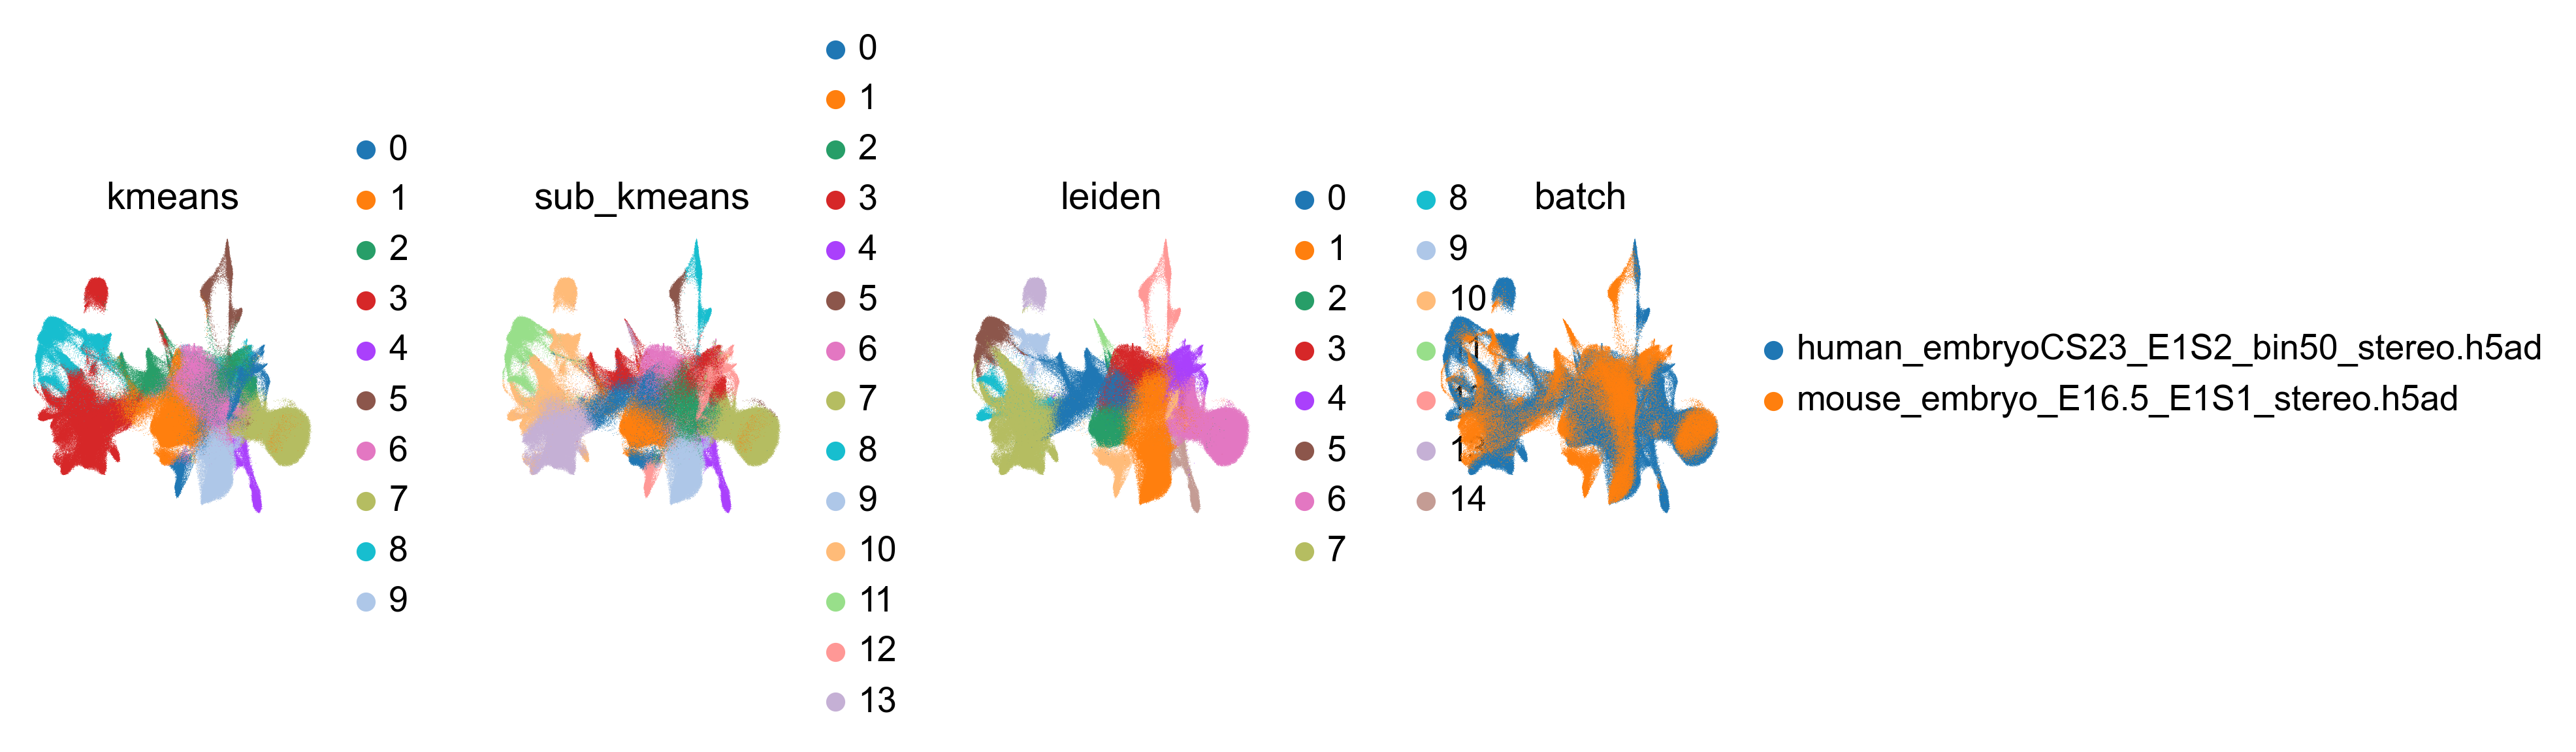

In [13]:
sc.pl.umap(adata_int, color=['kmeans', 'sub_kmeans', 'leiden', 'batch'], ncols=5)